In [ ]:
import numpy as np
import pandas as pd
import itertools

def compute_alpha(sigma, eps_r, mu_r, freq_hz):
    """Compute attenuation constant α in Np/m"""
    eps0 = 8.854e-12
    mu0  = 4 * np.pi * 1e-7
    omega = 2 * np.pi * freq_hz
    eps   = eps_r * eps0
    mu    = mu_r  * mu0

    term = np.sqrt(1 + (sigma / (omega * eps))**2) - 1
    alpha = omega * np.sqrt(mu * eps / 2) * np.sqrt(term)
    return alpha  # Np/m → multiply by 8.686 for dB/m

# Media parameters: (sigma, eps_r, mu_r)
media = {
    "seawater":  (4.0,  80.0, 1.0),
    "soil_wet":  (0.1,  15.0, 1.0),
    "tissue":    (0.5,  50.0, 1.0),
    "concrete":  (0.01, 6.0,  1.0),
    "dry_wood":  (0.001,2.0,  1.0),
}

rows = []
for name, (sigma_base, eps_r_base, mu_r_base) in media.items():
    sigmas = np.logspace(np.log10(sigma_base * 0.5),
                         np.log10(sigma_base * 2.0), 20)
    eps_rs  = np.linspace(eps_r_base * 0.8, eps_r_base * 1.2, 20)
    freqs   = np.logspace(6, 10, 25)   # 1 MHz – 10 GHz

    for sigma, eps_r, freq in itertools.product(sigmas, eps_rs, freqs):
        alpha = compute_alpha(sigma, eps_r, mu_r_base, freq)
        rows.append({
            "sigma": sigma, "eps_r": eps_r, "mu_r": mu_r_base,
            "freq_hz": freq, "alpha_npm": alpha,
            "alpha_dbm": alpha * 8.686, "medium": name
        })

df = pd.DataFrame(rows)
df.to_csv("attenuation_dataset.csv", index=False)
print(f"Generated {len(df)} samples")

Generated 50000 samples


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("attenuation_dataset.csv")
df = df.dropna()

# Log-scale frequency and sigma for numerical stability
df["log_freq"]  = np.log10(df["freq_hz"])
df["log_sigma"] = np.log10(df["sigma"])
df["log_alpha"] = np.log10(df["alpha_dbm"].clip(1e-10))

features = ["log_sigma", "eps_r", "mu_r", "log_freq"]
target   = "log_alpha"

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

import joblib
joblib.dump(scaler, "scaler.pkl")
np.save("X_train.npy", X_train); np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train); np.save("y_test.npy", y_test)
print("Preprocessing done.")

Preprocessing done.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0911 - mae: 0.1165 - val_loss: 5.7279e-04 - val_mae: 0.0185
Epoch 2/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.8093e-04 - mae: 0.0147 - val_loss: 2.3286e-04 - val_mae: 0.0112
Epoch 3/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.3052e-04 - mae: 0.0114 - val_loss: 1.5742e-04 - val_mae: 0.0093
Epoch 4/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6891e-04 - mae: 0.0097 - val_loss: 1.3420e-04 - val_mae: 0.0082
Epoch 5/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4649e-04 - mae: 0.0090 - val_loss: 1.6895e-04 - val_mae: 0.0096
Epoch 6/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2654e-04 - mae: 0.0083 - val_loss: 9.5450e-05 - val_mae: 0.0072
Epoch 7/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3033e-04 - mae: 0.0085 - val_loss: 8.8939e-05 - val_mae: 0.0071
Epoch 8/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0354e-04 - mae: 0.0075 - val_loss: 1.1244e-04 - val_

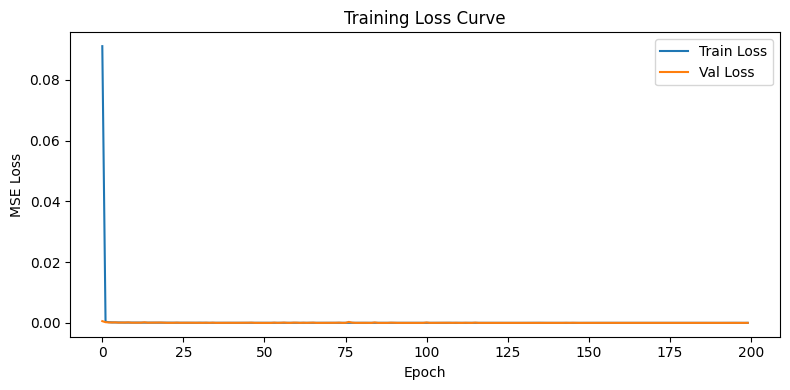

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

X_train = np.load("X_train.npy"); X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy"); y_test = np.load("y_test.npy")

model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),   # extra layer helps
    layers.Dense(1)                         # predicts log10(alpha)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=200, batch_size=64, verbose=1
)

model.save("attenuation_model.h5")

# Plot loss curves
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Training Loss Curve"); plt.legend(); plt.tight_layout()
plt.savefig("loss_curve.png"); plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
R²   : 1.0000
MAE  : 0.4636 dB/m
RMSE : 1.4271 dB/m


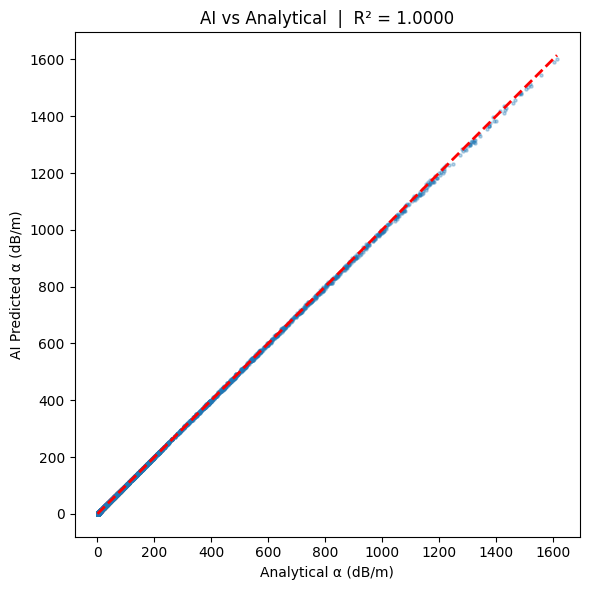

In [ ]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model  = keras.models.load_model("attenuation_model.h5", compile=False)
scaler = joblib.load("scaler.pkl")

X_test = np.load("X_test.npy"); y_test = np.load("y_test.npy")

y_pred = model.predict(X_test).flatten()

# Back to dB/m scale
y_actual = 10**y_test
y_predicted = 10**y_pred

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_actual, y_predicted)
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f} dB/m")
print(f"RMSE : {rmse:.4f} dB/m")

# Predicted vs Actual plot
plt.figure(figsize=(6,6))
plt.scatter(y_actual, y_predicted, alpha=0.3, s=5)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel("Analytical α (dB/m)"); plt.ylabel("AI Predicted α (dB/m)")
plt.title(f"AI vs Analytical  |  R² = {r2:.4f}")
plt.tight_layout(); plt.savefig("pred_vs_actual.png"); plt.show()

In [ ]:
import numpy as np, joblib
from tensorflow import keras

model  = keras.models.load_model("attenuation_model.h5", compile=False)
scaler = joblib.load("scaler.pkl")

# Example: unknown media at 2.4 GHz
sigma, eps_r, mu_r, freq = 0.3, 25.0, 1.0, 2.4e9

inp = np.array([[np.log10(sigma), eps_r, mu_r, np.log10(freq)]])
inp_scaled = scaler.transform(inp)
log_alpha  = model.predict(inp_scaled)[0][0]
alpha_db   = 10**log_alpha

print(f"Predicted attenuation: {alpha_db:.4f} dB/m")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Predicted attenuation: 97.0757 dB/m
